In [1]:
!pip install monai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.3 MB/s eta 0:00:00


# Importing libraries

In [2]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from PIL import Image
import timm
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torch.utils.data import WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.amp import autocast, GradScaler

from sklearn.model_selection import train_test_split
from glob import glob

from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.metrics import ConfusionMatrixDisplay
from monai.losses import FocalLoss

from sklearn.preprocessing import LabelBinarizer

from sklearn.metrics import f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.gridspec as gridspec

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

seed_everything(42)

BATCH_SIZE = 16
NUM_CLASSES = 4
EPOCHS = 25
LEARNING_RATE = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported succesfully!")

Using Device: cuda
Libraries imported succesfully!


In [3]:
root_path = '/kaggle/input/datasets/sethkyei/cxr-class/images/images'
labels = os.path.join(root_path, 'labels.csv')

In [4]:
# labels preprocessing

df = pd.read_csv(labels)
df.drop('Unnamed: 2', axis=1, inplace=True)

df.dropna(inplace=True)

df['actual'] = df['actual'].replace('pneumonia', 'other')

In [5]:
df['actual'].value_counts()

actual
other           368
normal          358
cardiomegaly    115
effusion         72
Name: count, dtype: int64

In [6]:
facilities = {
    "TTH": 0,
    "HMS": 0,
    "TCH": 0
}

for row in df['image_id'].values:
    facility = row.split('_')[0]
    facilities[facility] += 1

display(pd.DataFrame(facilities.items(), columns=['Facility', 'Count']))

,Facility,Count
0,TTH,344
1,HMS,276
2,TCH,293


In [7]:
df_train, df_temp = train_test_split(df, test_size=0.3, random_state=42, stratify=df['actual'])

df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=df_temp['actual'])

print(f"Training set size: {len(df_train)}")
print(f"Validation set size: {len(df_val)}")
print(f"Test set size: {len(df_test)}")

display(df_train.head())
display(df_val.head())
display(df_test.head())

Training set size: 639
Validation set size: 137
Test set size: 137


,image_id,actual
686,TCH_0008,other
699,TCH_0021,cardiomegaly
756,TCH_0078,normal
202,TTH_0204,cardiomegaly
163,TTH_0165,other


,image_id,actual
263,TTH_0265,other
790,TCH_0112,cardiomegaly
983,TCH_0305,normal
802,TCH_0124,normal
40,TTH_0042,other


,image_id,actual
255,TTH_0257,other
221,TTH_0223,other
584,HMS_0205,effusion
134,TTH_0136,other
630,HMS_0253,normal


# Folder structure

In [8]:
import shutil

imagefolder_base_path = os.path.join('/kaggle/working', 'images')

train_dir = os.path.join(imagefolder_base_path, 'train')
val_dir = os.path.join(imagefolder_base_path, 'val')
test_dir = os.path.join(imagefolder_base_path, 'test')

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

class_labels = df['actual'].unique()

for label in class_labels:
    os.makedirs(os.path.join(train_dir, label), exist_ok=True)
    os.makedirs(os.path.join(val_dir, label), exist_ok=True)
    os.makedirs(os.path.join(test_dir, label), exist_ok=True)

print("Folder structure created.")

Folder structure created.


# Copying Images

In [9]:
def copy_images(dataframe, dest_base_dir):
    for index, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        image_id = row['image_id'] + '.png'
        label = row['actual']
        search_pattern = os.path.join(root_path, f'*/{image_id}')
        source_path = glob(search_pattern)
        if len(source_path) > 0:
            source_path = source_path[0]
        else:
            print(f"Warning: Image not found for image_id: {image_id}")
            print(source_path)
            continue

        destination_path = os.path.join(dest_base_dir, label, image_id)

        if os.path.exists(source_path):
            shutil.copy(source_path, destination_path)
        else:
            print(f"Warning: Image not found at {source_path}")

copy_images(df_train, train_dir)
copy_images(df_val, val_dir)
copy_images(df_test, test_dir)

print("Image copying complete.")

  0%|          | 0/639 [00:00<?, ?it/s]

  0%|          | 0/137 [00:00<?, ?it/s]

  0%|          | 0/137 [00:00<?, ?it/s]

Image copying complete.


# Preprocessing

Loading sample image 1: /kaggle/working/images/train/other/TTH_0228.png
Loading sample image 2: /kaggle/working/images/train/cardiomegaly/TTH_0023.png


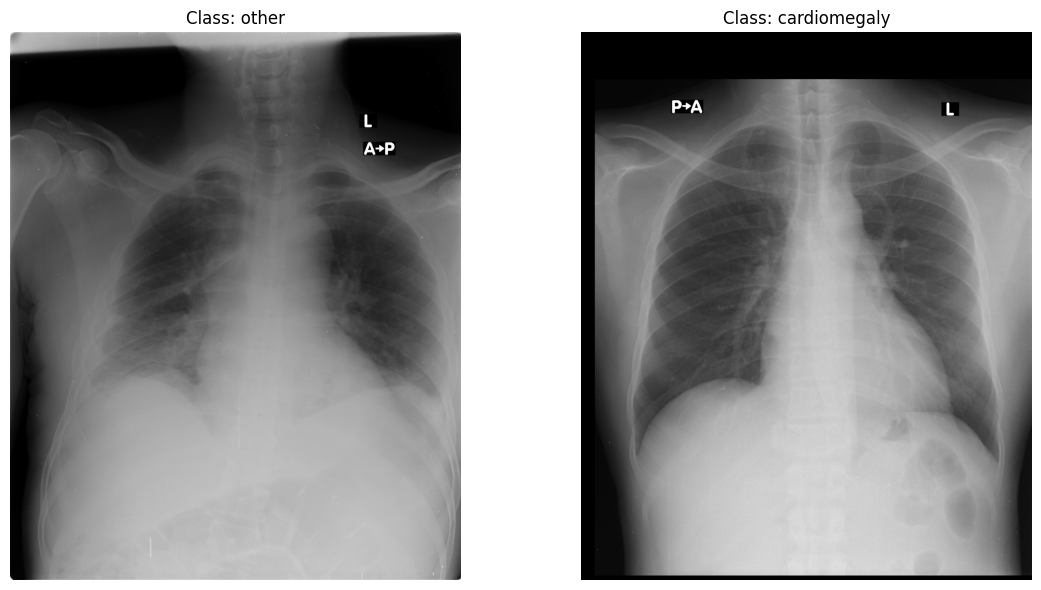

In [10]:
all_train_images = glob(os.path.join(train_dir, '*/*.png'))

# Ensure we have at least 2 images to display side-by-side
if len(all_train_images) >= 2:
    # Select 2 unique random images
    sample_image_paths = random.sample(all_train_images, 2)
    
    # Create a figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    for i, sample_image_path in enumerate(sample_image_paths):
        print(f"Loading sample image {i+1}: {sample_image_path}")
        
        # Load and convert image
        img = Image.open(sample_image_path).convert('RGB')
        
        # Plot in the respective subplot axis
        axes[i].imshow(img)
        axes[i].set_title(f"Class: {sample_image_path.split(os.sep)[-2]}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('sample_images')
    plt.show()

elif len(all_train_images) == 1:
    print("Only 1 image found. Plotting a single image instead.")
    img = Image.open(all_train_images[0]).convert('RGB')
    plt.imshow(img)
    plt.title(f"Sample Image (Class: {all_train_images[0].split(os.sep)[-2]})")
    plt.axis('off')
    plt.show()
    
else:
    print("No images found in the training directory. Please check your paths.")

In [11]:
# import torch
# from torchvision.datasets import ImageFolder
# import torchvision.transforms as transforms
# from torch.utils.data import DataLoader

# clean_transform = transforms.Compose([
#     transforms.Resize((224, 224)), 
#     transforms.ToTensor()
# ])

# clean_dataset = ImageFolder(train_dir, transform=clean_transform)
# clean_loader = DataLoader(clean_dataset, batch_size=32, shuffle=False)

# mean = torch.zeros(3)
# std = torch.zeros(3)
# total_images = 0

# for images, _ in clean_loader:
#     batch_samples = images.size(0)
#     # images shape: [batch_size, channels, height, width]
#     images = images.view(batch_samples, images.size(1), -1)
    
#     mean += images.mean(2).sum(0)
#     std += images.std(2).sum(0)
#     total_images += batch_samples

# mean /= total_images
# std /= total_images

# print(f"True Mean: {mean}")
# print(f"True Std: {std}")

In [12]:
from torchvision.datasets.folder import IMG_EXTENSIONS
# transforms
mean=[0.3674, 0.3676, 0.3678]
std=[0.2845, 0.2844, 0.2844]

IMG_SIZE = 256
# Data augmentation for training to improve model generalization
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),                    # Slight rotations
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Brightness & Contrast
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    )
])

# Standard transforms for validation and testing (No Augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    )
])

print("Transforms Initialized")

Transforms Initialized


In [13]:
# datasets
train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset = ImageFolder(val_dir, transform=val_test_transform)
test_dataset = ImageFolder(test_dir, transform=val_test_transform)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# class mapping
print("Class to index mapping:", train_dataset.class_to_idx)

train_labels = train_dataset.targets
num_normal = train_labels.count(0)
num_pneumonia = train_labels.count(1)
pos_weight = torch.tensor([num_normal / num_pneumonia]).to(DEVICE)
print(f"pos_weight = {pos_weight.item():.4f}")

class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

Train dataset size: 639
Validation dataset size: 137
Test dataset size: 137
Class to index mapping: {'cardiomegaly': 0, 'effusion': 1, 'normal': 2, 'other': 3}
pos_weight = 1.6000


In [14]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

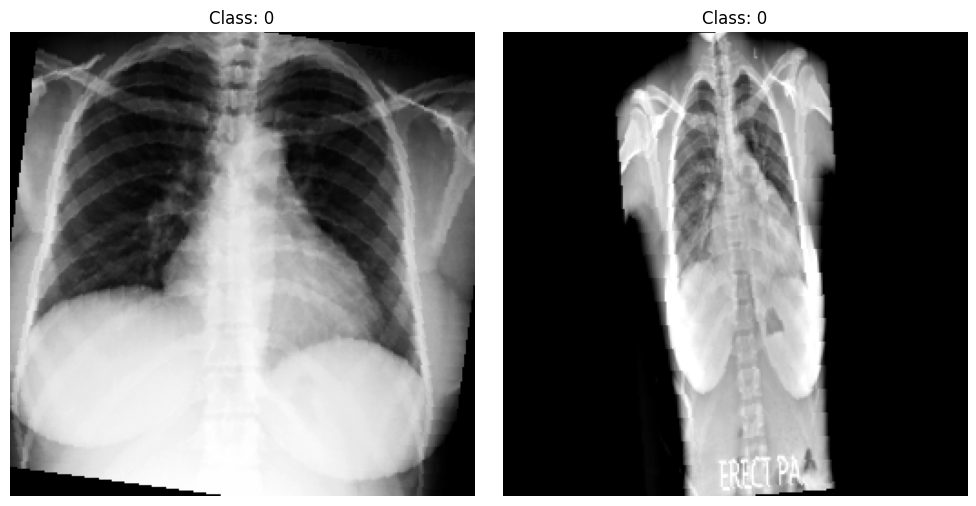

<Figure size 640x480 with 0 Axes>

In [15]:
images, labels = next(iter(train_loader))

# Check to ensure the batch size is at least 2
if images.shape[0] >= 2:
    # Create a 1x2 subplot grid
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Plot the first image in the batch (Index 0)
    axes[0].imshow(images[0, 0, :, :], cmap="gray")
    axes[0].set_title(f"Class: {labels[0].item()}")
    axes[0].axis('off')
    
    # Plot the second image in the batch (Index 1)
    axes[1].imshow(images[1, 0, :, :], cmap="gray")
    axes[1].set_title(f"Class: {labels[1].item()}")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    plt.savefig('preprocessed_images')
else:
    print(f"Your batch size is only {images.shape[0]}. Increase batch_size in your DataLoader to plot multiple images.")

In [16]:
class DenseNetClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()

        self.backbone = timm.create_model('densenet121', pretrained=True, num_classes=num_classes)

        in_features = self.backbone.classifier.in_features

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = DenseNetClassifier()

# Unfreeze classifier head
for param in model.backbone.classifier.parameters():
    param.requires_grad = True

# Unfreeze DenseNet denseblock4 as well
for name, param in model.backbone.named_parameters():
    if "denseblock4" in name:
        param.requires_grad = True


class EfficientNetClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        # Load pretrained efficientnet_b0
        self.backbone = timm.create_model('efficientnet_b0', pretrained=pretrained, num_classes=num_classes)
        
        # EfficientNet uses 'classifier' for its final layer
        in_features = self.backbone.classifier.in_features
        
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# Initialization
efficientnet_model = EfficientNetClassifier()

# Unfreeze the custom classifier head and final efficient blocks (blocks.6 and conv_head)
for name, param in efficientnet_model.backbone.named_parameters():
    if "blocks.6" in name or "conv_head" in name or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False  # Keep early layers frozen


class ResNetClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        # Load pretrained resnet50
        self.backbone = timm.create_model('resnet50', pretrained=pretrained, num_classes=num_classes)
        
        # ResNet uses 'fc' for its final classification layer
        in_features = self.backbone.fc.in_features
        
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# Initialization
resnet_model = ResNetClassifier()

# Unfreeze the custom classifier head and the final convolution block (layer4)
for name, param in resnet_model.backbone.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False  # Keep early layers frozen

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [17]:

from torch.amp import autocast, GradScaler
from collections import Counter


def calculate_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=1)
    return (preds == labels).float().mean().item()

def train_model(model, name="densenet_classifier"):
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    early_stop_patience = 5
    epochs_no_improve = 0

    mixup_fn = Mixup(
        mixup_alpha=0.8,       
        cutmix_alpha=1.0,      
        prob=1.0,              
        switch_prob=0.5,       
        mode='batch',          
        num_classes=NUM_CLASSES
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    # CalculatING class weights for CrossEntropyLoss based on inverse frequency
    class_counts = Counter(train_dataset.targets)
    total_samples = len(train_dataset)
    class_weights_list = [0.] * NUM_CLASSES
    for i in range(NUM_CLASSES):
        if class_counts[i] > 0:
            class_weights_list[i] = total_samples / class_counts[i]
        else:
            class_weights_list[i] = 1.0

    # Convert to tensor and move to device
    class_weights_tensor = torch.tensor(class_weights_list, dtype=torch.float).to(DEVICE)
    # Optionally, normalize weights so their average is 1, to prevent them from overly scaling the loss value
    class_weights_tensor = class_weights_tensor / class_weights_tensor.sum() * NUM_CLASSES

    # train_criterion = SoftTargetCrossEntropy()
    # train_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
    # val_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

    train_criterion = FocalLoss(gamma=2.0, alpha=0.25, to_onehot_y=True, use_softmax=True, reduction="mean")
    val_criterion = FocalLoss(gamma=2.0, alpha=0.25, to_onehot_y=True, use_softmax=True, reduction="mean")
    
    scaler = GradScaler(device="cuda")

    print(f"Starting training for {name}")
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Training - {name}]", leave=False):
            images = images.to(DEVICE)
            labels = labels.long().to(DEVICE)

            # images, labels = mixup_fn(images, labels)
            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(images)                 # [B, 2]
                loss = train_criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        val_acc = 0.0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Validating - {name}]", leave=False):
                images = images.to(DEVICE)
                labels = labels.long().to(DEVICE)

                with autocast(device_type='cuda'):
                    outputs = model(images)
                    loss = val_criterion(outputs, labels)

                val_loss += loss.item()
                val_acc += calculate_accuracy(outputs, labels)

        val_loss /= len(val_loader)
        val_acc /= len(val_loader)

        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), f'{name}_best.pth')
            print(f" >>> Best model saved! (Val Loss: {val_loss:.4f})")
        else:
            epochs_no_improve += 1
            print(f"   --- No improvement for {epochs_no_improve}/{early_stop_patience} epochs.")
            if epochs_no_improve >= early_stop_patience:
                print(f"\n EARLY STOPPING at Epoch {epoch+1}. Best Val Loss: {best_val_loss:.4f}")
                break

    return history

    print(f"Training Complete for {name}")


In [18]:
model_config = {
    'densenet': model,
    'resnet': resnet_model,
    'efficientnet': efficientnet_model
}

In [19]:
# model.to(DEVICE)
# history = train_model(model=model)

In [20]:
def plot_train_vs_val(history, model_name="Model"):
    plt.figure(figsize=(7, 5))

    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")

    plt.title(f"{model_name}: Train vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# plot_train_vs_val(history, "DenseNet")

Starting training for densenet


Epoch 1/25 [Training - densenet]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/25 [Validating - densenet]:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch [1/25] | Train Loss: 0.0592 | Val Loss: 0.0510 | Val Acc: 0.3480
 >>> Best model saved! (Val Loss: 0.0510)


Epoch 2/25 [Training - densenet]:   0%|          | 0/40 [00:00<?, ?it/s]

...

Epoch 10/25 [Validating - densenet]:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch [10/25] | Train Loss: 0.0118 | Val Loss: 0.0361 | Val Acc: 0.6698
   --- No improvement for 4/5 epochs.


Epoch 11/25 [Training - densenet]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 11/25 [Validating - densenet]:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch [11/25] | Train Loss: 0.0106 | Val Loss: 0.0413 | Val Acc: 0.6466
   --- No improvement for 5/5 epochs.

 EARLY STOPPING at Epoch 11. Best Val Loss: 0.0352


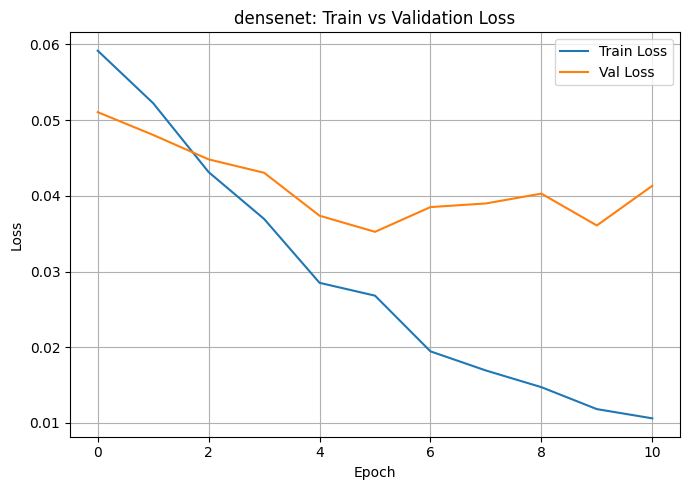

Starting training for resnet


Epoch 1/25 [Training - resnet]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/25 [Validating - resnet]:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch [1/25] | Train Loss: 0.0682 | Val Loss: 0.0618 | Val Acc: 0.1181
 >>> Best model saved! (Val Loss: 0.0618)


Epoch 2/25 [Training - resnet]:   0%|          | 0/40 [00:00<?, ?it/s]

...

Epoch 5/25 [Validating - resnet]:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch [5/25] | Train Loss: 0.0611 | Val Loss: 0.0620 | Val Acc: 0.1181
   --- No improvement for 4/5 epochs.


Epoch 6/25 [Training - resnet]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 6/25 [Validating - resnet]:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch [6/25] | Train Loss: 0.0595 | Val Loss: 0.0631 | Val Acc: 0.1181
   --- No improvement for 5/5 epochs.

 EARLY STOPPING at Epoch 6. Best Val Loss: 0.0618


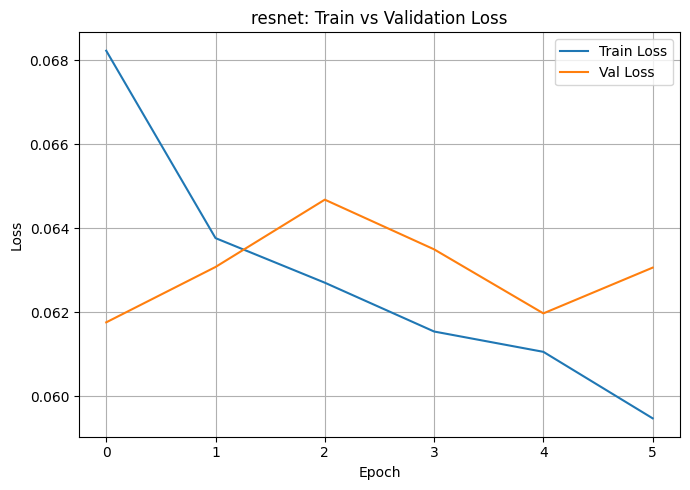

Starting training for efficientnet


Epoch 1/25 [Training - efficientnet]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/25 [Validating - efficientnet]:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch [1/25] | Train Loss: 0.0644 | Val Loss: 0.0596 | Val Acc: 0.1319
 >>> Best model saved! (Val Loss: 0.0596)


Epoch 2/25 [Training - efficientnet]:   0%|          | 0/40 [00:00<?, ?it/s]

...

Epoch 24/25 [Validating - efficientnet]:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch [24/25] | Train Loss: 0.0204 | Val Loss: 0.0321 | Val Acc: 0.6366
 >>> Best model saved! (Val Loss: 0.0321)


Epoch 25/25 [Training - efficientnet]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 25/25 [Validating - efficientnet]:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch [25/25] | Train Loss: 0.0198 | Val Loss: 0.0348 | Val Acc: 0.6119
   --- No improvement for 1/5 epochs.


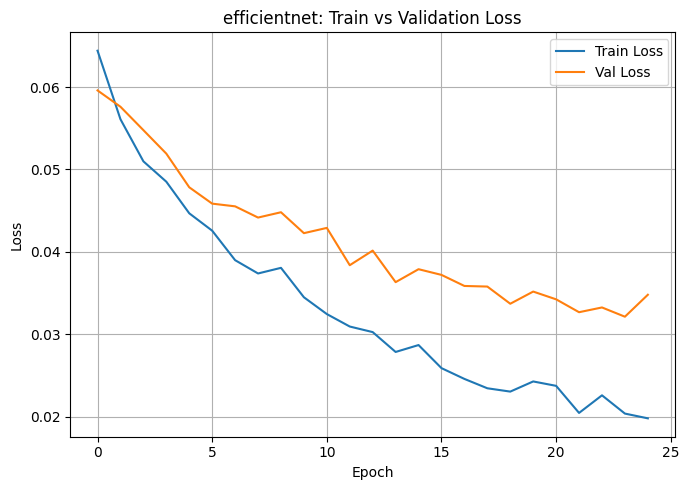

In [21]:
for name, m  in model_config.items():
    m.to(DEVICE)
    results = train_model(m, name=name)
    plot_train_vs_val(results, model_name=name)

In [22]:
def evaluate_model(name, model):
    results = {}
    base_path = "/kaggle/working/"

    CLASS_NAMES = train_dataset.classes
    print(CLASS_NAMES)
    print("\n==============================")
    print(f" Evaluating: {name}")
    print("============================")
    
    try:
        # Load best checkpoint
        ckpt_path = os.path.join(base_path, f"{name}_best.pth")
    
        if os.path.exists(ckpt_path):
            model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
            print(f"Loaded weights for {name}")
        else:
            print("Checkpoint not found. Using current model weights.")
    
        model = model.to(DEVICE)
        model.eval()
    
        all_labels = []
        all_preds = []
        all_probs = [] # Store probabilities for all classes
    
        # Test loop
        with torch.no_grad():
            for images, labels in tqdm(test_loader, desc=f"Evaluating Test Set - {name}"):
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)
    
                with autocast(device_type="cuda"):
                    logits = model(images)
                    probs = torch.softmax(logits, dim=1)
    
                preds = torch.argmax(probs, dim=1)
    
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy()) # Collect probabilities for all classes
    
        # Convert to numpy
        all_labels = np.array(all_labels)
        all_preds = np.array(all_preds)
        all_probs = np.array(all_probs)
    
        # Metrics
        f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    
        try:
            # Calculate multi-class AUC using 'one-vs-rest' strategy
            auc_score = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        except ValueError as e:
            print(f"Could not calculate AUC: {e}")
            auc_score = float("nan")
    
        cm = confusion_matrix(all_labels, all_preds)
    
        print("-----------------------------------------------------")
        print(f" {name} TEST RESULTS")
        print("-----------------------------------------------------")
        print(f"Macro F1-Score : {f1_macro:.4f}")
        print(f"AUC-ROC        : {auc_score:.4f}")
        print(classification_report(
            all_labels,
            all_preds,
            target_names=CLASS_NAMES,
            zero_division=0
        ))
    
        # Plot results
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
        ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=CLASS_NAMES
        ).plot(ax=axes[0], cmap="Blues", colorbar=False)
    
        axes[0].set_title(f"{name} - Test Confusion Matrix")
    
        if not np.isnan(auc_score):
            # For multi-class, plot one-vs-rest ROC curves for each class
            lb = LabelBinarizer()
            lb.fit(all_labels)
            all_labels_onehot = lb.transform(all_labels)
    
            for i, class_name in enumerate(CLASS_NAMES):
                fpr, tpr, _ = roc_curve(all_labels_onehot[:, i], all_probs[:, i])
                class_auc = roc_auc_score(all_labels_onehot[:, i], all_probs[:, i])
                axes[1].plot(fpr, tpr, label=f"{class_name} (AUC = {class_auc:.3f})")
    
            axes[1].plot([0, 1], [0, 1], "--", color='grey', linestyle='--', label='Random Classifier')
            axes[1].set_title(f"{name} - Test ROC Curves (OvR)")
            axes[1].set_xlabel("False Positive Rate")
            axes[1].set_ylabel("True Positive Rate")
            axes[1].legend(loc="lower right")
            
            
            axes[1].grid(True)
        else:
            axes[1].text(0.5, 0.5, "ROC not available",
                         ha="center", va="center")
            axes[1].set_title("ROC Curve")
    
        plt.tight_layout()
        plt.savefig(f'{name}_results')
        plt.show()
    
        # Save results
        results[name] = {
            "f1": f1_macro,
            "auc": auc_score
        }
    
    except Exception as e:
        print(f"{name} evaluation failed: {e}")

In [23]:
# evaluate_model('DenseNet', model)

Starting test evaluation...
['cardiomegaly', 'effusion', 'normal', 'other']

 Evaluating: densenet
Loaded weights for densenet


Evaluating Test Set - densenet:   0%|          | 0/9 [00:00<?, ?it/s]

-----------------------------------------------------
 densenet TEST RESULTS
-----------------------------------------------------
Macro F1-Score : 0.5306
AUC-ROC        : 0.7910
              precision    recall  f1-score   support

cardiomegaly       0.36      0.67      0.47        18
    effusion       0.33      0.45      0.38        11
      normal       0.71      0.91      0.79        53
       other       0.86      0.33      0.47        55

    accuracy                           0.61       137
   macro avg       0.56      0.59      0.53       137
weighted avg       0.69      0.61      0.59       137



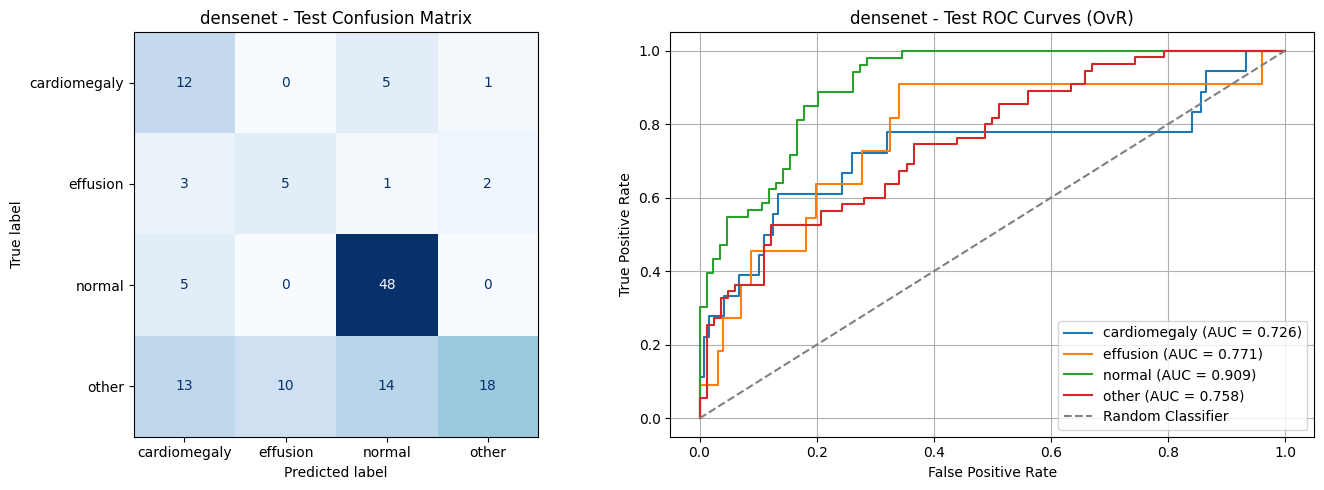

Starting test evaluation...
['cardiomegaly', 'effusion', 'normal', 'other']

 Evaluating: resnet
Loaded weights for resnet


Evaluating Test Set - resnet:   0%|          | 0/9 [00:00<?, ?it/s]

-----------------------------------------------------
 resnet TEST RESULTS
-----------------------------------------------------
Macro F1-Score : 0.0581
AUC-ROC        : 0.5910
              precision    recall  f1-score   support

cardiomegaly       0.13      1.00      0.23        18
    effusion       0.00      0.00      0.00        11
      normal       0.00      0.00      0.00        53
       other       0.00      0.00      0.00        55

    accuracy                           0.13       137
   macro avg       0.03      0.25      0.06       137
weighted avg       0.02      0.13      0.03       137



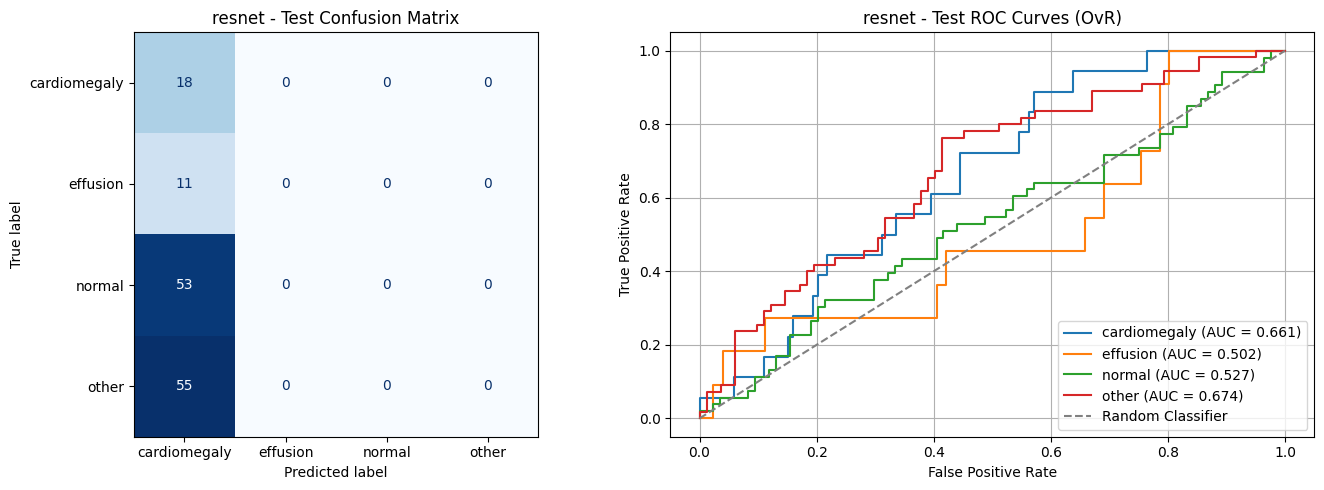

Starting test evaluation...
['cardiomegaly', 'effusion', 'normal', 'other']

 Evaluating: efficientnet
Loaded weights for efficientnet


Evaluating Test Set - efficientnet:   0%|          | 0/9 [00:00<?, ?it/s]

-----------------------------------------------------
 efficientnet TEST RESULTS
-----------------------------------------------------
Macro F1-Score : 0.4404
AUC-ROC        : 0.7876
              precision    recall  f1-score   support

cardiomegaly       0.28      0.56      0.37        18
    effusion       0.20      0.27      0.23        11
      normal       0.67      0.74      0.70        53
       other       0.68      0.35      0.46        55

    accuracy                           0.52       137
   macro avg       0.46      0.48      0.44       137
weighted avg       0.59      0.52      0.52       137



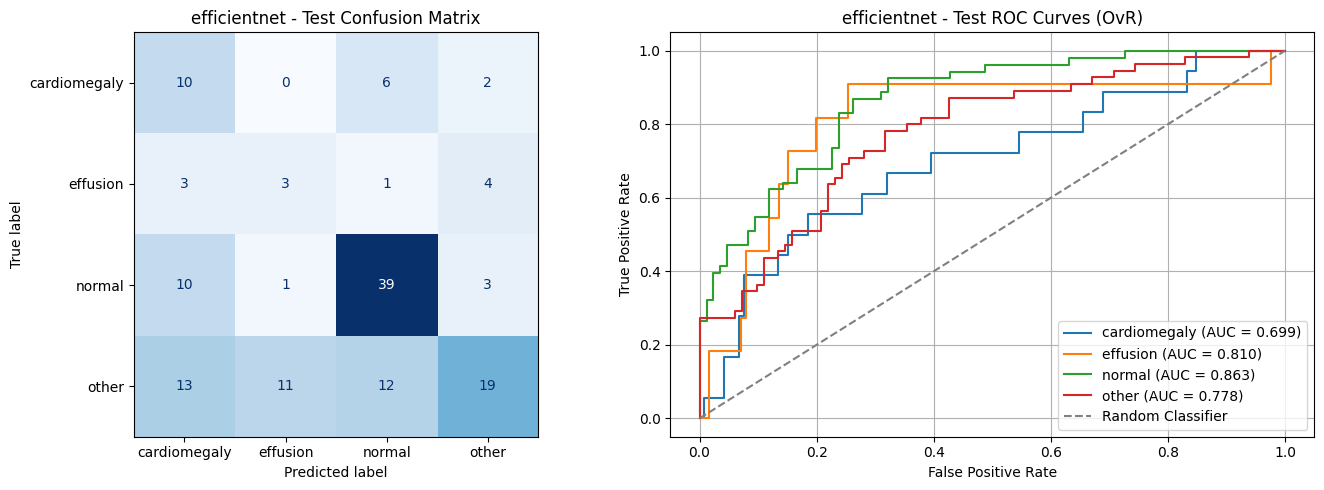

In [24]:
for name, m  in model_config.items():
    print("Starting test evaluation...")
    evaluate_model(name, m)